# CIFAR-10 Image Classification with ResNet18
This notebook trains a ResNet18 model on the CIFAR-10 dataset using PyTorch with GPU acceleration.

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import random
import os

print(f'PyTorch Version : {torch.__version__}')
print(f'CUDA Available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch Version : 2.6.0+cu124
CUDA Available  : True
GPU             : NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Seed Everything


In [2]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

## 3. Config

In [3]:
BATCH_SIZE  = 128      # Increased from 32 — faster training, fine for RTX 3050
NUM_EPOCHS  = 50       # Fixed: was 10, need 50+ for 80%+ accuracy
LR          = 0.1      # Fixed: SGD needs higher LR than Adam
NUM_CLASSES = 10
SUBSET_SIZE = 500      # Fixed 500-image test subset for all MR experiments

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

os.makedirs('checkpoints', exist_ok=True)

Using device: cuda


## 4. Data Loading

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')

d:\Metamorphic\cifar_resnet\cifar_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples : 50000
Test samples     : 10000


## 5. Fix 500-Image Test Subset (ONCE — saved for all phases)

In [5]:
SUBSET_PATH = 'checkpoints/test_subset_indices.npy'

if not os.path.exists(SUBSET_PATH):
    all_targets   = np.array(test_dataset.targets)
    subset_indices = []
    for cls in range(10):
        cls_idx = np.where(all_targets == cls)[0]
        chosen  = np.random.choice(cls_idx, 50, replace=False)
        subset_indices.extend(chosen.tolist())
    subset_indices = np.array(subset_indices)
    np.save(SUBSET_PATH, subset_indices)
    print(f'Saved 500-image subset → {SUBSET_PATH}')
else:
    subset_indices = np.load(SUBSET_PATH)
    print(f'Loaded existing subset  → {SUBSET_PATH}')

subset_loader = DataLoader(
    Subset(test_dataset, subset_indices),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

Loaded existing subset  → checkpoints/test_subset_indices.npy


## 6. Visualize Sample Images

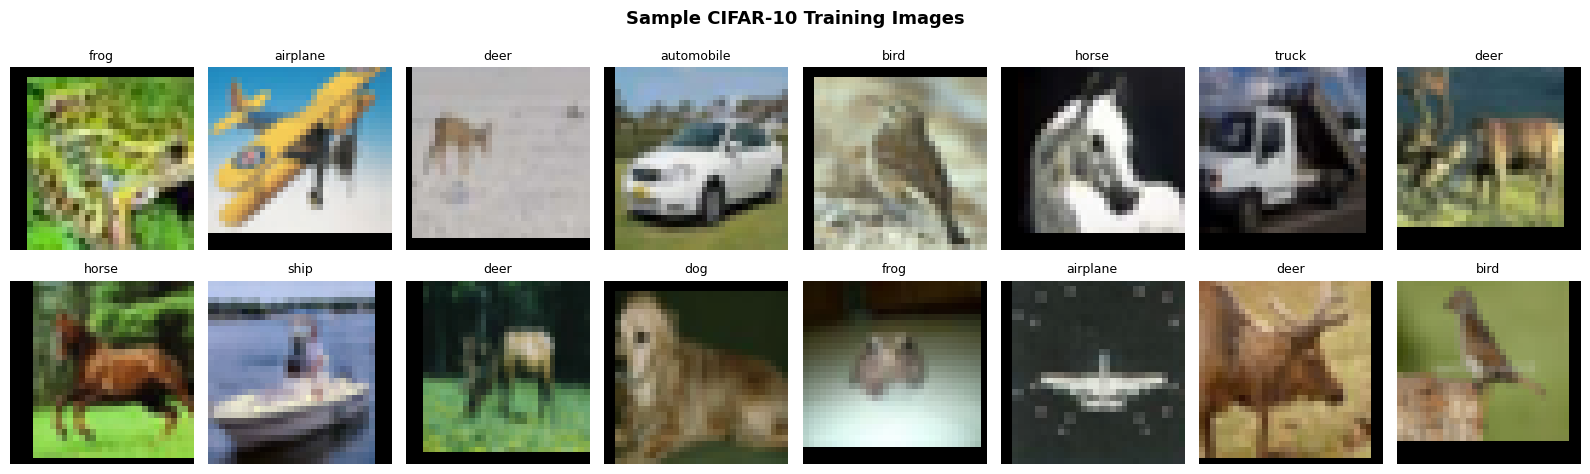

In [6]:
def imshow(img):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img  = img.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    return np.clip(img, 0, 1)

dataiter       = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imshow(images[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Build ResNet-18 for CIFAR-10 

In [7]:
model = resnet18(weights=None)
model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc     = nn.Linear(model.fc.in_features, NUM_CLASSES)
model        = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')


Total parameters     : 11,173,962
Trainable parameters : 11,173,962


## 8. Loss, Optimizer & Scheduler

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR,         # Fixed: was Adam
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(        # Fixed: was StepLR
                      optimizer, T_max=NUM_EPOCHS)

scaler = torch.cuda.amp.GradScaler()

C:\Users\jenis\AppData\Local\Temp\ipykernel_14968\1068330819.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 9. Training & Evaluation Functions

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / len(loader.dataset)


## 10. Train the Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>12} "
      f"{'Val Loss':>10} {'Val Acc':>10} {'Subset Acc':>12}")
print('-' * 68)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                             optimizer, criterion, scaler)
    val_loss, val_acc     = evaluate(model, test_loader,  criterion)
    _, subset_acc         = evaluate(model, subset_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6}/{NUM_EPOCHS} {train_loss:>12.4f} {train_acc:>11.2f}% "
          f"{val_loss:>10.4f} {val_acc:>9.2f}% {subset_acc:>11.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc

print('-' * 68)
print(f'Best Val Accuracy : {best_val_acc:.2f}%')


 Epoch   Train Loss    Train Acc   Val Loss    Val Acc   Subset Acc
--------------------------------------------------------------------


C:\Users\jenis\AppData\Local\Temp\ipykernel_14968\2616169424.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\jenis\AppData\Local\Temp\ipykernel_14968\2616169424.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     1/50       2.0734       25.41%     1.6056     39.83%       43.00%
     2/50       1.4575       46.17%     1.2863     53.81%       54.60%
     3/50       1.1315       58.87%     1.0575     61.03%       61.40%


## 11. Plot Training Curves

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss vs Epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy vs Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True)

plt.suptitle('ResNet18 on CIFAR-10 — Model A', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Per-Class Accuracy

In [ ]:
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        for i in range(len(labels)):
            lbl = labels[i].item()
            class_correct[lbl] += (preds[i] == labels[i]).item()
            class_total[lbl]   += 1

print(f"\n{'Class':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print('-' * 45)
accs = []
for i in range(NUM_CLASSES):
    acc = 100.0 * class_correct[i] / class_total[i]
    accs.append(acc)
    print(f"{CLASSES[i]:<15} {class_correct[i]:>8} {class_total[i]:>8} {acc:>9.2f}%")

plt.figure(figsize=(12, 5))
bars = plt.bar(CLASSES, accs, color='steelblue', edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy — Model A', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 13. Save the Model

In [ ]:
final_val_loss, final_val_acc = evaluate(model, test_loader, criterion)
_, final_subset_acc           = evaluate(model, subset_loader, criterion)

torch.save({
    'model_state_dict' : model.state_dict(),
    'val_accuracy'     : final_val_acc,
    'subset_accuracy'  : final_subset_acc,
    'seed'             : SEED,
    'epochs'           : NUM_EPOCHS,
    'optimizer'        : 'SGD',
    'scheduler'        : 'CosineAnnealingLR',
}, 'checkpoints/model_a.pth')

print(f'\nModel A saved → checkpoints/model_a.pth')
print(f'Val accuracy      : {final_val_acc:.2f}%')
print(f'Subset accuracy   : {final_subset_acc:.2f}%')
print(f'Subset indices    : checkpoints/test_subset_indices.npy')
print('\n✓ Phase 1 complete. Ready for Phase 1 Step 1.2 (MR definitions).')

## 14. Quick Inference Test

In [ ]:
loaded_model = resnet18(weights=None)
loaded_model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
loaded_model.maxpool = nn.Identity()
loaded_model.fc     = nn.Linear(loaded_model.fc.in_features, NUM_CLASSES)
loaded_model.load_state_dict(
    torch.load('checkpoints/model_a.pth', map_location=device)['model_state_dict']
)
loaded_model = loaded_model.to(device)
loaded_model.eval()
print('\nModel loaded and verified successfully!')

idx          = np.random.randint(0, len(test_dataset))
image, true_label = test_dataset[idx]
with torch.no_grad():
    pred = loaded_model(image.unsqueeze(0).to(device)).argmax(1).item()

plt.figure(figsize=(4, 4))
plt.imshow(imshow(image))
color = 'green' if pred == true_label else 'red'
plt.title(f'Predicted: {CLASSES[pred]}\nActual: {CLASSES[true_label]}',
          color=color, fontweight='bold')
plt.axis('off')
plt.show()